# ADP 실기 31회 기출 풀이 

## 1. 주어진 데이터를 활용하여, 비만 수준을 예측하라.
Data description  : 'Obesity.csv' <br>
Gender : 성별 <br>
Age : 나이 <br>
Height : 키 <br>
Weight : 몸무게 <br>
family_history_with_overweight : 가족 중 과체중인 사람이 있는지 여부 <br>
FAVC : 고칼로리 식품을 자주 섭취하는지 여부 <br>
FCVC : 채소 섭취 빈도 <br>
NCP : 식사 횟수 <br>
CAEC : 간식 섭취 빈도 <br>
SMOKE : 흡연 여부 <br>
CH20 : 물을 섭취 빈도 <br>
SCC : 섭취 칼로리를 모니터링하는지 여부 <br>
FAF : 운동 빈도 <br>
TUE : 전자제품(휴대폰, TV, 비디오게임 등) 사용 빈도 <br>
CALC : 알코올 섭취 빈도 <br>
MTRANS : 주로 이용하는 교통 수단 <br>
BMI: Body mass index

* 종속변수:
NObeyesda( 비만 수)준 <br>   -
Insufficient_Weight : 저체중 <br>   -
Normal_Weight : 정상 체중 <br>   -
Overweight_Level : 과체중 수준(I ~ II) <br>   -
Obesity_Type : 비만 유형(I ~ III

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

In [67]:
d1 = pd.read_csv("https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/31/adp_31_1_obesity_v2.csv",index_col=0)
d1.head(3)

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,4,male,27,1.80,87,no,no,always,3,sometimes,no,between 1 and 2 l,no,2 to 4,0 to 2,frequently,walking,overweight_level_i,26.851852
1,11,male,26,1.85,105,yes,yes,always,3,frequently,no,more than 2 l,no,2 to 4,>5,sometimes,public_transportation,obesity_type_i,30.679328
2,14,male,41,1.80,99,no,yes,sometimes,3,sometimes,no,between 1 and 2 l,no,2 to 4,3 to 5,frequently,automobile,obesity_type_i,30.555556


In [68]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1262 entries, 0 to 1261
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1262 non-null   object 
 1   Gender                          1262 non-null   object 
 2   Age                             1262 non-null   int64  
 3   Height                          1262 non-null   float64
 4   Weight                          1262 non-null   int64  
 5   family_history_with_overweight  1262 non-null   object 
 6   FAVC                            1262 non-null   object 
 7   FCVC                            1262 non-null   object 
 8   NCP                             1262 non-null   int64  
 9   CAEC                            1262 non-null   object 
 10  SMOKE                           1262 non-null   object 
 11  CH2O                            1262 non-null   object 
 12  SCC                             12

id는 식별자 역할만 하므로 모델학습에 사용하지 않는다.(추후 삭제)  
결측치는 없다. 

### 1-1]  데이터 분포를 살펴보고 특성을 기술하시오.EDA & 결측치 및 이상치를 판단하고 설명하라

In [69]:
d1.isna().mean()

id                                0.000000
Gender                            0.000000
Age                               0.000000
Height                            0.000000
Weight                            0.000000
family_history_with_overweight    0.000000
FAVC                              0.000000
FCVC                              0.000000
NCP                               0.000000
CAEC                              0.000000
SMOKE                             0.000000
CH2O                              0.000000
SCC                               0.002377
FAF                               0.000000
TUE                               0.000000
CALC                              0.000000
MTRANS                            0.000000
NObeyesdad                        0.000000
BMI                               0.000000
dtype: float64

SCC에 아주 작은 비율의 결측치가 존재한다. 0.002% 수준으로 데이터에서 큰 비중을 차지하지 않으며, 데이터에 데한 사전지식이 없어 다른 값으로 보간하는 것보다 삭제가 적절하므로 삭제한다. 

In [70]:
d1 = d1.dropna()

<<연속/이산형 변수>>


,count,mean,std,min,25%,50%,75%,max
Age,1259.0,25.754567,9.908531,15.000000,21.000000,24.000000,27.000000,150.000000
Height,1259.0,1.708876,0.091233,1.450000,1.631439,1.710616,1.775582,1.980000
Weight,1259.0,101.023034,21.490752,53.000000,82.000000,105.000000,116.000000,173.000000
NCP,1259.0,2.664813,0.757869,1.000000,3.000000,3.000000,3.000000,4.000000
BMI,1259.0,34.431891,6.102283,22.826739,30.715939,34.343740,38.919026,50.811753


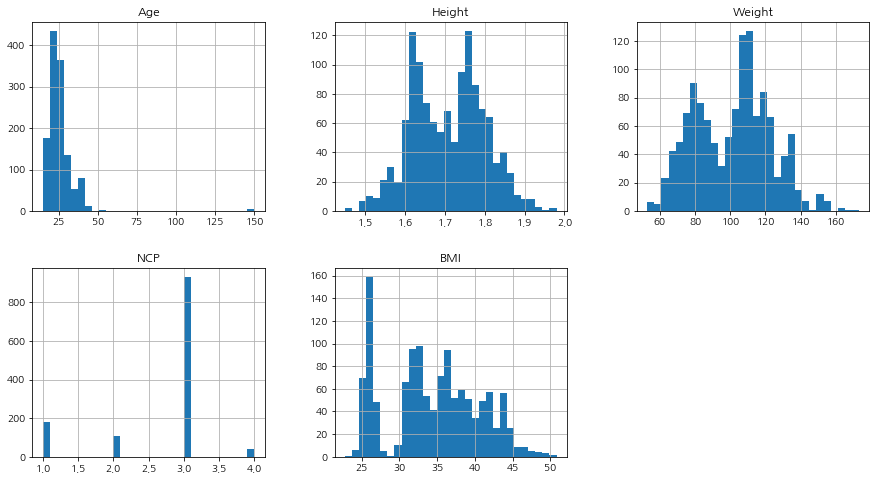

<<명목형 변수>>


,count,unique,top,freq
Gender,1259,2,male,634
family_history_with_overweight,1259,2,yes,1170
FAVC,1259,2,yes,1218
FCVC,1259,3,always,628
CAEC,1259,4,sometimes,1187
SMOKE,1259,2,no,1234
CH2O,1259,3,between 1 and 2 l,617
SCC,1259,2,no,1219
FAF,1259,4,1 to 2,480
TUE,1259,3,0 to 2,614


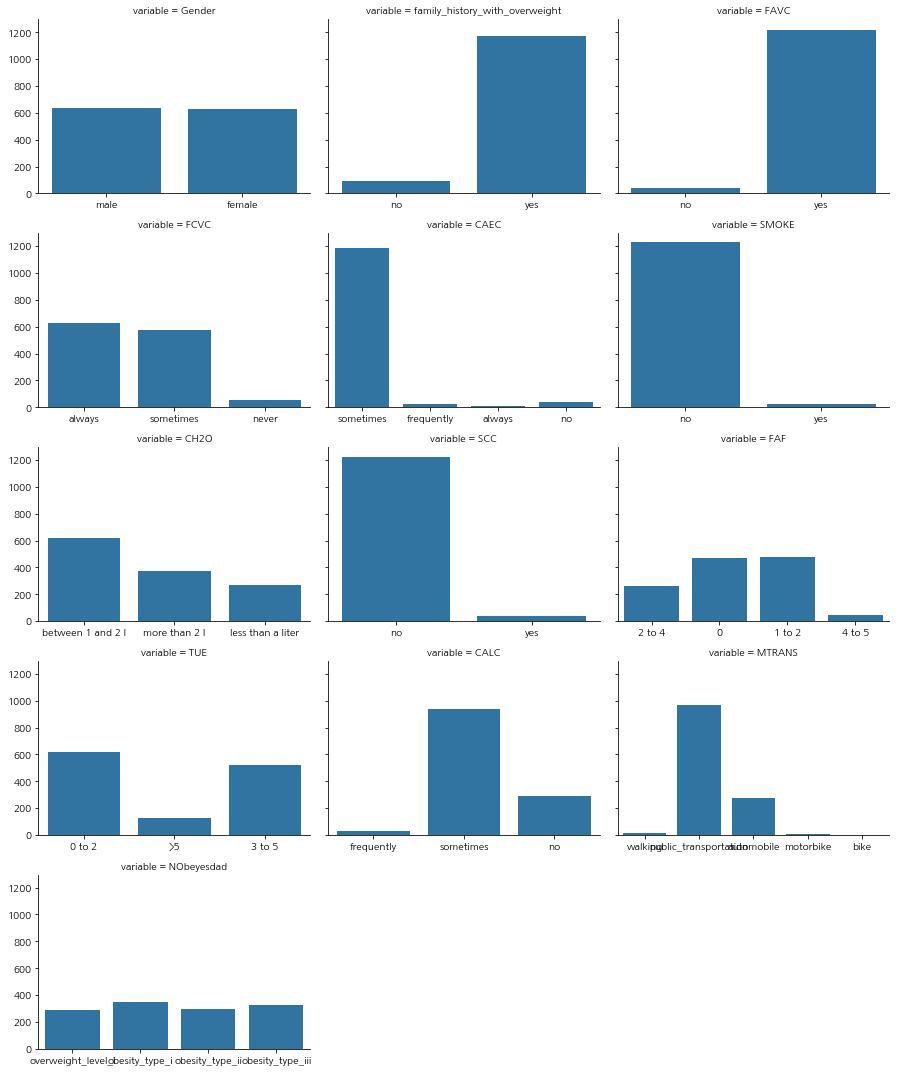

In [71]:
cat_cols = d1.select_dtypes('object').columns[1:]
num_cols = d1.select_dtypes('number').columns

print("<<연속/이산형 변수>>")
display(d1[num_cols].describe().T)
d1[num_cols].hist(figsize=(15, 8), bins=30, layout=(2, 3))
plt.show()

print("<<명목형 변수>>")
display(d1[cat_cols].describe(include='O').T)
mt = d1[cat_cols].melt()
g = sns.FacetGrid(
    mt,
    col="variable",
    col_wrap=3,# 행표시 개수
    height=3,# 그래프의 세로 크기
    aspect=1.4, # 그래프의 가로/세로 비율
    sharex=False # x축 완전 독립
)
g.map_dataframe(sns.countplot, x="value")
plt.tight_layout()
plt.show()

연속형 변수
- 나이는 오른쪽 긴꼬리 분포를 보이며, 이상치(150세)가 탐지됨
- 키는 1.6, 1.8에서 쌍봉분포를 보임
- NCP는 3.0이 다른 값들이 비해 매우 높은 비율을 차지함
- BMI도 0~30미만, 30~50으로 쌍봉분포를 보임

명목형 변수
- 성별 비율은 거의 비슷함
- 비만가족이력, FAVC가 있는 사람의 비율이 압도적으로 높음
- FCVC는 never가 다른 2개 범주값보다 압도적으로 적음
- SCC는 no가 압도적으로 높음
- CALC 는 sometimes가 가장 높고 가끔이 가장 낮음
- 교통수단은 공용수단이 가장 높고, 자전거가 가장 낮음
- 비만수준 비율은 비슷한 편임

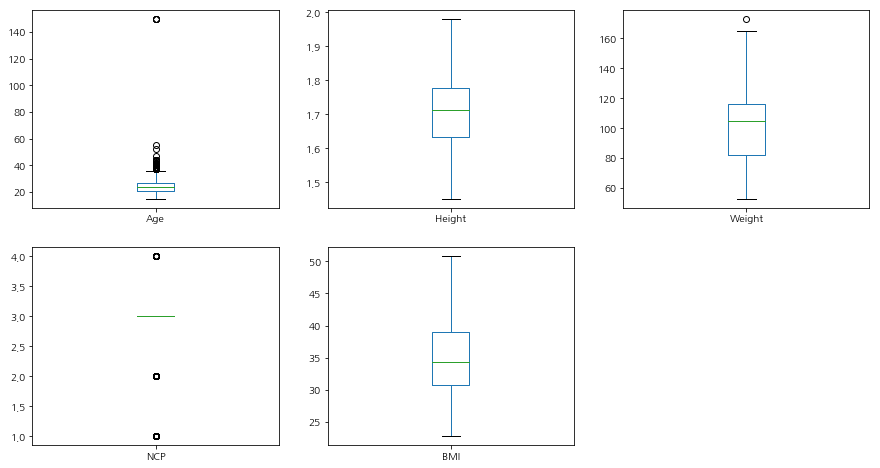

In [72]:
d1[num_cols].plot.box(subplots=True, figsize=(15, 8), layout=(2, 3))
plt.show()

boxplot으로 간단하게 연속형 변수의 이상치를 판단해본다.  
데이터 사전지식이 없기 때문에 분포에서 멀리 떨어진 값을 이상치로 단정지을 수는 없다.  
하지만 나이가 150세인 경우는 현실적으로 존재하지 않기 때문에 수집과정에서의 오류로 간주하고 삭제한다.   
(이상치 비율이 낮기 때문에[5개] 보간보다 삭제)

In [73]:
print(f"이상치 삭제 전 데이터 수: {len(d1)}")
d1 = d1[d1['Age'] < 150]
print(f"이상치 삭제 후 데이터 수: {len(d1)}")

이상치 삭제 전 데이터 수: 1259
이상치 삭제 후 데이터 수: 1254


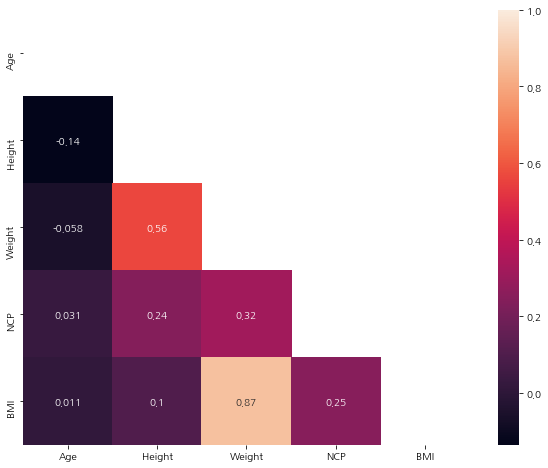

In [74]:
plt.figure(figsize=(10, 8))
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

다음으로 각 연속변수 간 피어슨 선형상관관계를 확인한다.  
변수 간 1:1 관계에서 bmi-몸무게 0.87의 비교적 높은 양의 상관관계를 식별할 수 있었다.   
이는 몸무게가 늘면 BMI 또한 선형적으로 증가함을 의미한다. 

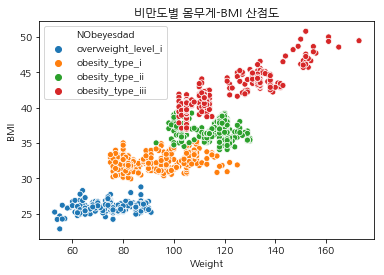

In [75]:
sns.scatterplot(data=d1, x='Weight', y='BMI', hue='NObeyesdad')
plt.title('비만도별 몸무게-BMI 산점도')
plt.show()

비만도별 몸무게-BMI 산점도를 통해 몸무게-BMI 값이 비만도에 따라 분류되는 경계가 있는 경향이 확인되었다. 

In [76]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame(columns=['name', 'vif']) #데이터프레임화

vif['name'] = num_cols #독립변수명
vif['vif'] = [variance_inflation_factor(d1[num_cols].values, i) for i in range(len(num_cols))]
display(vif[1:])

,name,vif
1,Height,54.784213
2,Weight,116.049571
3,NCP,15.007239
4,BMI,123.431775


또한 vif를 확인했을 때 10 이상의 매우 높은 다중공선성이 있는 것으로 확인되었다.  

### 1-2] 데이터 전처리 기법 2가지를 설명하고 주어진 데이터에 적용시 어떤 효과가 있는지 설명하라.

1. 앞서 EDA를 통해 독립변수 간 다중공선성을 확인했다. 다중공선성은 회귀분석에서 두 개 이상의 독립 변수(설명 변수) 사이에   
   강한 선형 상관관계가 존재하는 상태로 공선성이 높으면 계수 추정치의 분산이 커져 예측 및 해석 신뢰도가 떨어지고,   
   모델 학습 과정에서도 수렴 속도를 늦추거나 최적화 경로를 왜곡할 수 있으므로 PCA 등 차원축소 방식을 통해  
   다중공선성을 완화해야 한다. 
2. 스케일링(standard scaler 채택): 연속형 변수의 각기 다른 스케일을 정규분포 가정하여 -1~1사이값으로 맞춤으로써(평균0, 분산1) 모델의  
   다양한 기계학습 알고리즘(특히 선형회귀, 로지스틱 회귀, SVM, KNN, PCA 등)의 학습 안정성과 정확도를 높이는데 효과적  
   해당 데이터의 연속형 변수 또한 각 변수마다 범위가 제각각이므로 스케일링을 통해 범위를 일치시킨다.
    - 각 변수의 단위 차이를 제거하여 모델 학습이 특정 변수에 치우치지 않도록 함
    - 경사하강법 기반 알고리즘의 수렴 속도 개선
    - 거리 기반 알고리즘(KNN, SVM 등)에서 필수적

### 1-3] 피쳐 엔지니어링을 통해 파생변수 1개를 생성하고 그 이유를 말하라

앞서 EDA에서 각 비만도별로 BMI의 경계가 나타나는 것을 식별하였다. 이를 통해 BMI도 4개 레벨로 분류한다.(카테고리화)  
어느정도 명확히 값이 분류가 된다면 연속형 변수에 비해 분류문제 학습 시 성능향상을 기대할 수 있다.

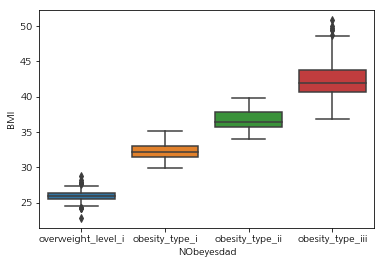

In [42]:
sns.boxplot(data=d1, x='NObeyesdad', y='BMI')
plt.show()

In [43]:
d1.groupby('NObeyesdad')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
NObeyesdad,,,,,,,,
obesity_type_i,347.0,32.260083,1.126101,29.911958,31.402133,32.203812,32.973741,35.171095
obesity_type_ii,296.0,36.732270,1.283258,34.048509,35.753610,36.418410,37.884250,39.786652
obesity_type_iii,322.0,42.274572,2.552838,36.774400,40.607079,41.942617,43.837706,50.811753
overweight_level_i,289.0,25.988723,0.661045,22.826739,25.574891,25.971277,26.387981,28.769607


비만도별 BMI 통계량을 보면 과체중 1과 비만1은 완벽하게 분리가 되고, 나머지 구간은 일부가 겹치지만 대체로  
분류가 가능한 수준인 것을 알 수 있다.   

따라서 비만 1~3까지는 사분위수 기반 경계 평균(이전 구간 3분위수+다음구간 1분위수/2)값을 기준으로 분류구간을 정한다.   

[34.3610765 39.249169 ]


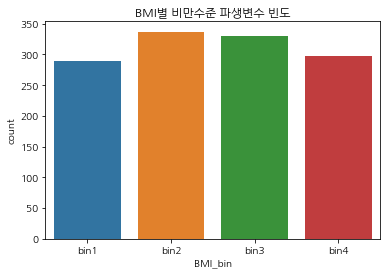

In [44]:
front = np.array([32.971628, 37.880693]) #이전구간 3분위수
back = np.array([35.750525, 40.617645]) #다음구간 1분위수

print((front+back)/2)

bins = [0, 29, 34.3610765, 39.249169, 51] #앞서 구한 카테고리 경계값

labels = ['bin1', 'bin2', 'bin3', 'bin4']
d1['BMI_bin'] = pd.cut(d1['BMI'], bins=bins, labels=labels) 

sns.countplot(d1['BMI_bin'] )
plt.title('BMI별 비만수준 파생변수 빈도')
plt.show()

다음과 같이 BMI 기반의 카테고리 변수가 생성된 것을 확인할 수 있다.

### 1-4] 앙상블을 제외한 분류 모델 3가지 구축 및 결과 비교 및 설명하라

1. 의사결정나무: 데이터를 분류하거나 예측하기 위한 트리(Tree) 구조의 모델이며, 조건을 담은 노드와 노드를 잇는 엣지로 구성,  
   불순도(엔트로피, 지니불순도)를 최소화하도록 선택하며, 데이터를 조건에 따라 반복적으로 분할하여 예측 결과 도출
    - 장점: 해석이 쉽고 시각화 가능, 범주형, 수치형 변수 모두 처리 가능, 스케일링 불필요, 이상치나 결측치에 강건함
    - 단점: 과적합 가능성 높음(트리크기 제한), 작은 변화에 민감함(데이터가 조금만 달라져도 구조바뀜),  
      일반화 성능 낮음,데이터 밖의 새로운 데이터 예측 불가
2. SVM: 분류되는 데이터를 학습하여 새로운 데이터가 어느 클래스에 속할지 판단하는 비확률적 선형 분류모델     
    - 장점: 데이터의 특성이 적어도 복잡한 결정경계 생성 가능, 저/고차원 데이터 적합함
    - 단점: 대용량 데이터에서 잘 작동하지 않음, 스케일링 등 전처리와 매개변수 설정이 까다로움,  
      예측결과에 대한 모델 설명이 어려움
3. MLP: 인공신경망 기본모델로 input-hidden(여러층 가능)-output layer로 구성되어 비선형 활성화 함수를 적용하여 뛰어난   
   모델 성능을 보임, 모델구조, 데이터에 따라 학습시간이 많이 소요될 수 있으며, 하이퍼파라미터 튜닝이 필요

In [45]:
d1.drop(columns=['id', 'BMI'] , inplace=True)

In [46]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

#종속, 설명변수 분할
Y = d1['NObeyesdad']
X = d1.drop(columns='NObeyesdad')

# 데이터 8:2 분할
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

cat_cols = train_X.select_dtypes(exclude='number').columns
num_cols = train_X.select_dtypes('number').columns

#데이터 전처리기
pre_processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), num_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols), 
    remainder='passthrough'
)

#모델링
dt = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', DecisionTreeClassifier(random_state=42))
    ])

svm = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', SVC(probability=True, random_state=42))
    ])
mlp = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', MLPClassifier(random_state=42))
    ])

#모델학습 및 평가
from sklearn.metrics import accuracy_score, classification_report

model_list = [('의사결정나무', dt), ('svm', svm), ('mlp', mlp)]
dt_list = [('train', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'accuracy'])

for m_name, model in model_list:
    model.fit(train_X, train_Y)
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        proba = model.predict_proba(x)
        score = accuracy_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, score]
        print(classification_report(y, pred))
display(rs) 

                    precision    recall  f1-score   support

    obesity_type_i       1.00      1.00      1.00       252
   obesity_type_ii       1.00      1.00      1.00       233
  obesity_type_iii       1.00      1.00      1.00       244
overweight_level_i       1.00      1.00      1.00       211

          accuracy                           1.00       940
         macro avg       1.00      1.00      1.00       940
      weighted avg       1.00      1.00      1.00       940

                    precision    recall  f1-score   support

    obesity_type_i       0.99      0.97      0.98        95
   obesity_type_ii       0.95      0.97      0.96        63
  obesity_type_iii       0.99      1.00      0.99        78
overweight_level_i       1.00      1.00      1.00        78

          accuracy                           0.98       314
         macro avg       0.98      0.98      0.98       314
      weighted avg       0.98      0.98      0.98       314

                    precision    r

,name,data,accuracy
0,의사결정나무,train,1.000000
1,의사결정나무,test,0.984076
2,svm,train,0.991489
3,svm,test,0.984076
4,mlp,train,1.000000
5,mlp,test,0.993631


위에서 선정한 3개의 모델을 활용하여 다중분류 모델을 적합 후 성능을 비교하였다.  
각 클래스 간 불균형이 없으므로 일반적인 성능척도인 정확도를 기준으로 모델성능을 비교할 때,  
test set 기준으로 성능이 가장 좋은 mlp 모델을 선정한다. 
(모든 모델에서 과적합은 없었다.)

### 1-5] 1-4에서 사용한 모델 중 하나를 골라 그리드 서치를 통해서 파라미터 튜닝 및 분류 모델 성능 평가 (precision ,recall)

그리드 서치를 통해 학습률을 0.01~0.2까지 0.02 간격으로 조정하여 5fold방식으로 파라미터 튜닝을 통해 최적의 하이퍼파라미터를   
구한 후 정밀도, 재현율로 성능을 비교한다. 

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score

param1 = {'classifier__learning_rate_init': np.arange(0.01, 0.2, 0.02)}

mlp_best = GridSearchCV(
    estimator = mlp, 
    param_grid = param1, 
    cv = 5, 
    scoring = 'recall_macro'
)
mlp_best.fit(train_X, train_Y)
print(f"best param: {mlp_best.best_params_}")
print(f"best score: {mlp_best.best_score_}")

rs = pd.DataFrame(columns=['name', 'data', 'precision', 'recall', 'acc', 'f1'])

for d_name, x, y in dt_list:
    pred = mlp_best.predict(x)
    proba = mlp_best.predict_proba(x)
    precision = precision_score(y, pred, average='macro')
    recall = recall_score(y, pred, average='macro')
    f1 = f1_score(y, pred, average='macro')
    acc = accuracy_score(y, pred)
    rs.loc[len(rs)] = ['MLP 그리드서치', d_name, precision, recall, acc, f1]
    print(classification_report(y, pred))
display(rs)

best param: {'classifier__learning_rate_init': 0.15}
best score: 0.9908876290571733
                    precision    recall  f1-score   support

    obesity_type_i       1.00      1.00      1.00       252
   obesity_type_ii       1.00      1.00      1.00       233
  obesity_type_iii       1.00      1.00      1.00       244
overweight_level_i       1.00      1.00      1.00       211

          accuracy                           1.00       940
         macro avg       1.00      1.00      1.00       940
      weighted avg       1.00      1.00      1.00       940

                    precision    recall  f1-score   support

    obesity_type_i       0.99      0.99      0.99        95
   obesity_type_ii       1.00      0.98      0.99        63
  obesity_type_iii       1.00      1.00      1.00        78
overweight_level_i       0.99      1.00      0.99        78

          accuracy                           0.99       314
         macro avg       0.99      0.99      0.99       314
      weigh

,name,data,precision,recall,acc,f1
0,MLP 그리드서치,train,1.000000,1.0000,1.000000,1.000000
1,MLP 그리드서치,test,0.994204,0.9934,0.993631,0.993776


5-fold 그리드 서치 방식으로 mlp 모델의 최적의 하이퍼 파라미터로 최적화하였다. 학습률0.15 일 떄, recall 0.9908876290571733로 최적의 성능을 낸다.

### 1-6]  Accuracy, Precision, Recall, F1 score를 계산하시오.

테스트셋 기준, 클래스 평균 점수로 계산한다.  
- precision: 0.994204
- recall: 0.9934	
- f1 score: 0.993631	
- accuracy: 0.993776

정확도, 정밀도, 재현율, 조화평균 모두 높은 성능을 보여줌으로 각 클래스를 잘 예측해냄을 보여준다. 

### 1-7] 1-4의 3가지 모델을 soft voting을 이용하여 모델링 한 결과와 1-5과 비교하라


In [48]:
from sklearn.ensemble import VotingClassifier

soft_v = VotingClassifier(
    estimators = [
        ('dt', dt), 
        ('svm', svm), 
        ('mlp', mlp)
    ], voting='soft'
)
soft_v.fit(train_X, train_Y)

for d_name, x, y in dt_list:
    pred = soft_v.predict(x)
    proba = soft_v.predict_proba(x)
    precision = precision_score(y, pred, average='macro')
    recall = recall_score(y, pred, average='macro')
    f1 = f1_score(y, pred, average='macro')
    acc = accuracy_score(y, pred)
    rs.loc[len(rs)] = ['soft voting', d_name, precision, recall, acc, f1]
    print(classification_report(y, pred))
display(rs)

                    precision    recall  f1-score   support

    obesity_type_i       1.00      1.00      1.00       252
   obesity_type_ii       1.00      1.00      1.00       233
  obesity_type_iii       1.00      1.00      1.00       244
overweight_level_i       1.00      1.00      1.00       211

          accuracy                           1.00       940
         macro avg       1.00      1.00      1.00       940
      weighted avg       1.00      1.00      1.00       940

                    precision    recall  f1-score   support

    obesity_type_i       0.99      0.99      0.99        95
   obesity_type_ii       0.98      0.98      0.98        63
  obesity_type_iii       1.00      1.00      1.00        78
overweight_level_i       1.00      1.00      1.00        78

          accuracy                           0.99       314
         macro avg       0.99      0.99      0.99       314
      weighted avg       0.99      0.99      0.99       314



,name,data,precision,recall,acc,f1
0,MLP 그리드서치,train,1.000000,1.0000,1.000000,1.000000
1,MLP 그리드서치,test,0.994204,0.9934,0.993631,0.993776
2,soft voting,train,1.000000,1.0000,1.000000,1.000000
3,soft voting,test,0.993400,0.9934,0.993631,0.993400


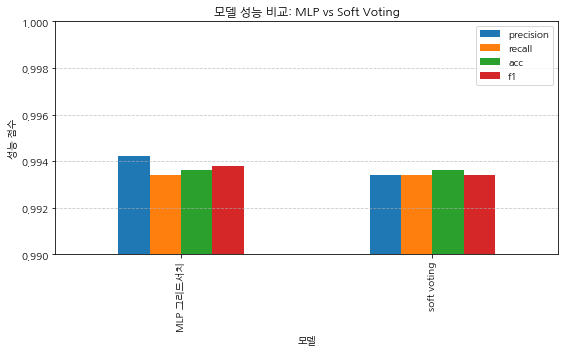

In [49]:
tmp = rs[rs['data'] == 'test'].drop(columns=['data'])
tmp = tmp.set_index('name')
ax = tmp.plot(kind='bar', figsize=(8, 5))

# 축 레이블 및 제목 설정
ax.set_xlabel('모델')
ax.set_ylabel('성능 점수')
ax.set_title('모델 성능 비교: MLP vs Soft Voting')
ax.set_ylim(0.99, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

큰 성능의 차이는 없으나, 그리드 서치를 통한 하이퍼파라미터 최적화 모델의 성능이 전반적으로 더 뛰어난 것을 알 수 있다. 

### 1-8] 하나의 모델을 선정하여 Drop Column Importance 방식으로 각 변수 별로 전체 컬럼을 포함한 모델과의 recall 값의 차이를 계산하고 시각화 하라

In [62]:
#최적의 모델 mlp 스켈레톤
full_model_score = recall_score(train_Y, mlp_best.predict(train_X), average='macro')

drop_imp = {}

for col in train_X.columns:
    tmp_X = train_X.drop(columns=col)
    cat_cols = tmp_X.select_dtypes(exclude='number').columns
    num_cols = tmp_X.select_dtypes('number').columns
    pre_processor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=0.8))]), num_cols), 
    (Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols), 
    remainder='passthrough')
    
    reduce_model = Pipeline([
    ('preprocessor', pre_processor), 
    ('classifier', MLPClassifier(random_state=42))
    ])
    
    reduce_model.fit(tmp_X, train_Y)
    reduce_score = recall_score(train_Y, reduce_model.predict(tmp_X), average='macro')
    drop_imp[col] = full_model_score - reduce_score
    #정규화
    tt = pd.Series(drop_imp)
    dci_score = (tt - tt.min())/(tt.max()-tt.min())
    dci_dt = pd.DataFrame(dci_score, columns=['성능차']).sort_values(by='성능차', ascending=False)
display(dci_dt)

,성능차
BMI_bin,1.000000
Age,0.128871
Weight,0.087051
NCP,0.045230
CALC,0.041820
FCVC,0.041820
SCC,0.000000
MTRANS,0.000000
TUE,0.000000
FAF,0.000000


In [61]:
drop_imp

{'Gender': 0.0,
 'Age': 0.003057088357517501,
 'Height': 0.0,
 'Weight': 0.0020650248654540126,
 'family_history_with_overweight': 0.0,
 'FAVC': 0.0,
 'FCVC': 0.0009920634920634885,
 'NCP': 0.0010729613733905241,
 'CAEC': 0.0,
 'SMOKE': 0.0,
 'CH2O': 0.0,
 'SCC': 0.0,
 'FAF': 0.0,
 'TUE': 0.0,
 'CALC': 0.0009920634920634885,
 'MTRANS': 0.0,
 'BMI_bin': 0.0237221282684843}

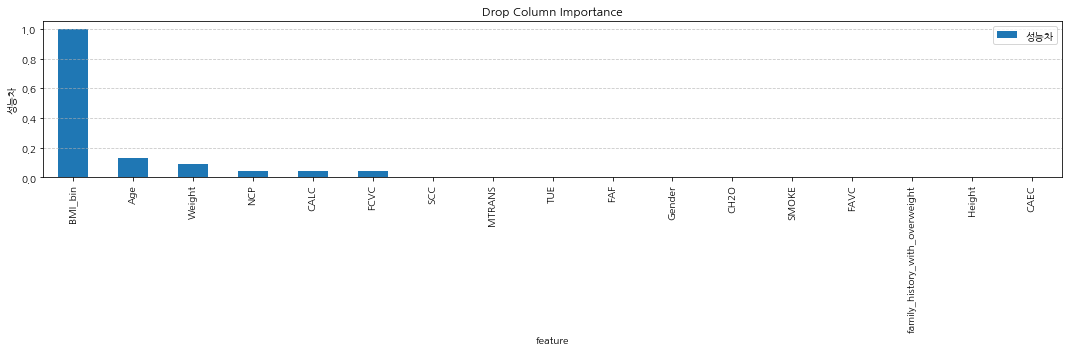

In [63]:
ax = dci_dt.plot(kind='bar', figsize=(15, 5))

# 축 레이블 및 제목 설정
ax.set_xlabel('feature')
ax.set_ylabel('성능차')
ax.set_title('Drop Column Importance')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

full 모델과 reduce 모델의 성능 차(recall)를 보여준다.(full recall score - reduce score)  
이 결과값이 작다는 것은 해당 feature를 제거하여도 full모델과 성능차가 없다는 것을 의미한다.  
결과값이 크다는 것은 해당 feature를 제거했을 때, 성능차이가 크다는 것을 의미한다.
BMI_bin이 가장 큰 영향을 미치며, Gender 등 11개 변수를 삭제하였을 시는 모델학습에 큰 영향을 미치지 않는 것을 알 수 있다.

## 2. 데이터를 이용해서 적정 체중 여부를 예측하라.


데이터 : 'bmi.csv'

. 만나이 : (검진날짜-생년월일)/365, 소수점 버림

.BMI :몸무게/키 **2 ( 키는 m기준), 소수점 둘째자리 반올림

. 성별과 만나이에 따른 BMI기준표


적정 체중 여부 (BMI가 아래 구간에 들어올 경우)
- 17세 남자 : 21.03이상 23.21 미만/
- 17세 여자 : 20.03이상 22.39 미만/
- 16세 남자 : 21.18이상 23.45 미만/
- 16세 여자 : 19.61이상 21.74 미만



In [25]:
d2 =pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/31/adp_31_2_v2.csv')
d2.head()

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별
0,ID_4135,169.01,65.47,20041003,2020_11_15,1,2,1,4.4,8.3,남성
1,ID_3289,181.62,69.36,19970725,2014_11_20,0,3,0,4.4,6.9,남성
2,ID_1847,160.89,65.12,20020921,2020_01_28,1,1,1,1.7,9.6,여성
3,ID_4785,162.21,62.28,20020106,2018_09_27,1,4,0,5.1,6.8,남성
4,ID_5693,159.13,54.11,19980708,2015_03_03,0,4,1,0.3,8.5,여성


In [26]:
d2.isna().mean()

ID         0.0
키          0.0
weight     0.0
생년월일       0.0
건강검진일      0.0
공학여부       0.0
채소섭취정도     0.0
아침식사여부     0.0
일주일운동시간    0.0
수면시간       0.0
성별         0.0
dtype: float64

### 2-1] 위 표를 바탕으로 파생변수(적정체중 여부)를 도출하고, 만나이와 파생변수(적정체중 여부)의 빈도표를 산출하시오.

In [27]:
# 만나이 계산
d2['건강검진일'] = pd.to_datetime(d2['건강검진일'], format='%Y_%m_%d')
d2['생년월일'] = pd.to_datetime(d2['생년월일'], format='%Y%m%d')
d2['만나이'] = np.floor((d2['건강검진일'] - d2['생년월일']).dt.days/365)
# BMI
d2['BMI'] = round(d2['weight']/((d2['키']/100)**2), 2)

d2.head(3)

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별,만나이,BMI
0,ID_4135,169.01,65.47,2004-10-03,2020-11-15,1,2,1,4.4,8.3,남성,16.0,22.92
1,ID_3289,181.62,69.36,1997-07-25,2014-11-20,0,3,0,4.4,6.9,남성,17.0,21.03
2,ID_1847,160.89,65.12,2002-09-21,2020-01-28,1,1,1,1.7,9.6,여성,17.0,25.16


In [81]:
cond1 = (d2['만나이'] == 17)&(d2['성별'] == '남성')&(d2['BMI'] >= 21.03)&(d2['BMI'] < 23.21) 
cond2 = (d2['만나이'] == 17)&(d2['성별'] == '여성')&(d2['BMI'] >= 20.03)&(d2['BMI'] < 22.39) 
cond3 = (d2['만나이'] == 16)&(d2['성별'] == '남성')&(d2['BMI'] >= 21.18)&(d2['BMI'] < 23.45) 
cond4 = (d2['만나이'] == 16)&(d2['성별'] == '여성')&(d2['BMI'] >= 19.61)&(d2['BMI'] < 21.74) 

d2['적정체중'] = np.where(cond1|cond2|cond3|cond4, 1, 0)

cr = pd.crosstab(d2['만나이'], d2['적정체중'])
display(cr)

적정체중,0,1
만나이,,
16.0,1086,2029
17.0,1722,1964


In [82]:
d2[(d2['만나이'] == 16)&(d2['성별'] == '여성')&(d2['BMI'].between(21.74, 21.75))].head()

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별,만나이,BMI,적정체중
744,ID_6463,156.03,52.94,2004-06-17,2021-02-18,1,3,1,9.2,8.4,여성,16.0,21.75,0
4277,ID_5024,150.36,49.14,2002-10-03,2018-12-21,0,4,0,7.5,6.4,여성,16.0,21.74,0
5519,ID_6488,152.65,50.66,1998-12-02,2015-06-03,0,3,0,7.5,6.8,여성,16.0,21.74,0


In [83]:
# 이걸 쓰면 안됨 right값도 포함됨
cond1 = (d2['만나이'] == 17)&(d2['성별'] == '남성')&(d2['BMI'].between(21.03, 23.21, inclusive='left')) #neither, right
cond2 = (d2['만나이'] == 17)&(d2['성별'] == '여성')&(d2['BMI'].between(20.03, 22.39, inclusive='left'))
cond3 = (d2['만나이'] == 16)&(d2['성별'] == '남성')&(d2['BMI'].between(21.18, 23.45, inclusive='left'))
cond4 = (d2['만나이'] == 16)&(d2['성별'] == '여성')&(d2['BMI'].between(19.61, 21.74, inclusive='left'))

d2['적정체중'] = np.where(cond1|cond2|cond3|cond4, 1, 0)

cr = pd.crosstab(d2['만나이'], d2['적정체중'])
display(cr)

적정체중,0,1
만나이,,
16.0,1083,2032
17.0,1718,1968


In [84]:
d2[(d2['만나이'] == 16)&(d2['성별'] == '여성')&(d2['BMI'].between(21.74, 21.75))].head()

,ID,키,weight,생년월일,건강검진일,공학여부,채소섭취정도,아침식사여부,일주일운동시간,수면시간,성별,만나이,BMI,적정체중
744,ID_6463,156.03,52.94,2004-06-17,2021-02-18,1,3,1,9.2,8.4,여성,16.0,21.75,0
4277,ID_5024,150.36,49.14,2002-10-03,2018-12-21,0,4,0,7.5,6.4,여성,16.0,21.74,1
5519,ID_6488,152.65,50.66,1998-12-02,2015-06-03,0,3,0,7.5,6.8,여성,16.0,21.74,1


### 2-2] 2-1에서 구한 적정 체중 여부와 나머지 컬럼(공학여부, 아침식사여부, 일주일운동시간, 채소섭취정도, 수면시간, 성별) 이 독립적인지 통계적으로 확인하라

In [10]:
cat_cols = ['공학여부', '아침식사여부', '채소섭취정도', '성별']
num_cols = ['일주일운동시간', '수면시간']

d2[cat_cols] = d2[cat_cols].astype('object')

종속변수인 적정체중 여부는 이진 범주형 변수이며, 독립성 검정을 위해서는  설명변수에 따라 다음과 같이 시행한다.

- 범주형 변수: 카이제곱 독립성 검정
- 연속형 변수: 독립검정 ttest(정규성 불만족 시 맨휘트니 u검정)

유의수준 5% 하에서 다음과 같은 가설수립 후 검정을 실시  


<가설수립>  
- 귀무가설: 적정체중 여부와 각 독립변수 간은 독립적이다.(연관성이 없다.)
- 대립가설: 적정체중 여부와 각 독립변수 간은 연관성이 있다.

In [11]:
from scipy.stats import ttest_ind, chi2_contingency

rs = pd.DataFrame(columns=['변수명', '통계량', 'p-value', '귀무가설 기각'])

# 카이제곱 독립성 검정
for col in cat_cols:
    cr = pd.crosstab(d2['적정체중'], d2[col])
    stat, p, ddof, expected = chi2_contingency(cr)
    rs.loc[len(rs)] = [col, stat, round(p, 2), p < 0.05]
display(rs)

,변수명,통계량,p-value,귀무가설 기각
0,공학여부,4.645187,0.03,True
1,아침식사여부,0.132440,0.72,False
2,채소섭취정도,10.438815,0.03,True
3,성별,0.021238,0.88,False


In [12]:
# 연속형 변수 독립성 검정
from scipy.stats import shapiro, levene, mannwhitneyu

for col in num_cols:
    gr = [group[col].values for name, group in d2.groupby(['적정체중'])]
    # 정규성 확인
    stat1, p1 = shapiro(gr[0])
    stat2, p2 = shapiro(gr[1])
    print(f"{col}: 정규성", "만족" if p1 > 0.05 and p2 > 0.05 else "불만족")
    stat, p = mannwhitneyu(*gr)
    rs.loc[len(rs)] = [col, stat, round(p, 2), p < 0.05]
display(rs)

일주일운동시간: 정규성 불만족
수면시간: 정규성 불만족


,변수명,통계량,p-value,귀무가설 기각
0,공학여부,4.645187e+00,0.03,True
1,아침식사여부,1.324401e-01,0.72,False
2,채소섭취정도,1.043881e+01,0.03,True
3,성별,2.123805e-02,0.88,False
4,일주일운동시간,5.554570e+06,0.55,False
5,수면시간,5.411168e+06,0.02,True


연속형 변수인 일주일 운동시간과 수면시간은 정규성을 만족하지 않아 비모수검정인 맨휘트니 u 검정을 실시하였다.  
검정결과, 유의수준 5% 하에서 통계적으로 유의(종속변수와 연관성이 있는)한 변수는 공학여부, 채소섭취정도, 수면시간이다.    
종속변수와 연관성이 있다는 것은 이를 통해 종속변수를 예측할 수 있음을 뜻한다.

### 2-3]  유의한 변수들만 가지고 Logistic regression과 XGBoost 모형을 적합하시오.

In [13]:
d2['적정체중'].value_counts()

1    4000
0    2801
Name: 적정체중, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

v_cols = ['공학여부', '채소섭취정도', '수면시간']

X = d2[v_cols]
Y = d2['적정체중']

train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42)

#카테고리 변수 더미화
train_X_d = pd.get_dummies(train_X, drop_first=True)
test_X_d = pd.get_dummies(test_X, drop_first=True)

#모델선언
lr = LogisticRegression(random_state=42)
xgb = XGBClassifier(random_state=42)

model_list = [lr, xgb]
#모델학습
for model in model_list:
    model.fit(train_X_d, train_Y)

In [15]:
from sklearn.metrics import accuracy_score, classification_report

model_list = [('Logistic', lr), ('xgbclassifier', xgb)]
dt_list = [('train', train_X_d, train_Y), ('test', test_X_d, test_Y)]

rs = pd.DataFrame(columns=['model', 'dt', 'acc'])
for m_name, model in model_list:
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        score = accuracy_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, score]
        print(classification_report(y, pred))
display(rs)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2123
           1       0.58      1.00      0.74      2977

    accuracy                           0.58      5100
   macro avg       0.29      0.50      0.37      5100
weighted avg       0.34      0.58      0.43      5100

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       678
           1       0.60      1.00      0.75      1023

    accuracy                           0.60      1701
   macro avg       0.30      0.50      0.38      1701
weighted avg       0.36      0.60      0.45      1701

              precision    recall  f1-score   support

           0       0.62      0.10      0.17      2123
           1       0.60      0.96      0.74      2977

    accuracy                           0.60      5100
   macro avg       0.61      0.53      0.45      5100
weighted avg       0.61      0.60      0.50      5100

              preci

,model,dt,acc
0,Logistic,train,0.583725
1,Logistic,test,0.601411
2,xgbclassifier,train,0.599608
3,xgbclassifier,test,0.590829


### 2-4] 회귀계수에 대해 오즈비로 해석하고, 통계적 유의성을 확인하시오.

In [17]:
import statsmodels.api as sm
train_X_l = sm.add_constant(train_X_d)
model = sm.Logit(train_Y, train_X_l).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.677995
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                   적정체중   No. Observations:                 5100
Model:                          Logit   Df Residuals:                     5093
Method:                           MLE   Df Model:                            6
Date:                Sat, 13 Sep 2025   Pseudo R-squ.:                0.001570
Time:                        09:33:08   Log-Likelihood:                -3457.8
converged:                       True   LL-Null:                       -3463.2
Covariance Type:            nonrobust   LLR p-value:                   0.09242
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0239      0.160     -0.149      0.882      -0.338       0.291
수면시간           0.0268      0.

In [18]:
np.exp(model.params)

const       0.976387
수면시간        1.027147
공학여부_1      1.108165
채소섭취정도_1    1.199564
채소섭취정도_2    1.065279
채소섭취정도_3    1.189044
채소섭취정도_4    1.144175
dtype: float64

모델의 우도비 검정결과, LLR p-value 0.06059로 유의수준 5% 하에서 유의하지 않은 모델임.  
(상수항만 있는 모델과 성능차이가 유의하다고 볼 수 없음)

각 컬럼의 p-value를 기준으로 유의수준 5% 하에서  
채소섭취정도_1, 채소섭취정도_3만 유의하다고 볼 수 있다.  

만약 모든 feature의 계수가 통계적으로 유의하다면 
다음과 같이 오즈비 해석을 할 수 있다.
- 기준: 공학여부: 0, 채소섭취정도: 0
1. 수면시간이 한 단위 증가할 때마다 적정체중이 될 오즈가 2.5% 증가
2. 공학이 아닌 경우에 비해 공학인 경우 적정체중이 될 오즈가 11.06% 증가
3. 채소섭취가 아예 없는 경우에 비해
  - 채소섭취 정도 1의 경우 적정체중이 될 오즈가 21.43% 증가
  - 2이 경우 적정체중이 될 오즈가 6.5% 증가
  - 3일 경우 적정체중이 될 오즈가 21.52% 증가
  - 4일 경우 적정체중이 될 오즈가 15.2% 증가

### 2-5] Feature importance와 Drop column importance를 활용하여, 변수를 선택하시오.

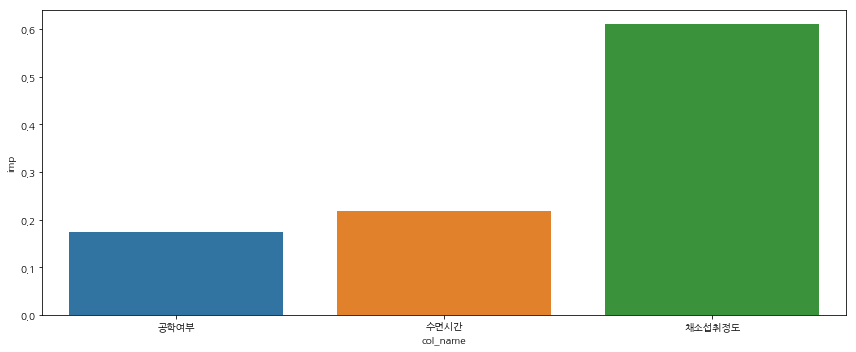

In [19]:
# feature imp
rs = pd.DataFrame(columns = ['col_name', 'imp'])
rs['col_name'] = train_X_d.columns
rs['imp'] = xgb.feature_importances_

rs['col_name'] = [parts[0] for parts in rs['col_name'].str.split('_')]
rs = rs.groupby(['col_name'])['imp'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=rs, x='col_name', y='imp')
plt.tight_layout()
plt.show()

채소섭취정도, 수면시간, 공학여부 순으로 모델학습에 중요한 영향을 준 것을 알 수 있다.  

,성능차
공학여부,0.0
채소섭취정도,0.6
수면시간,1.0


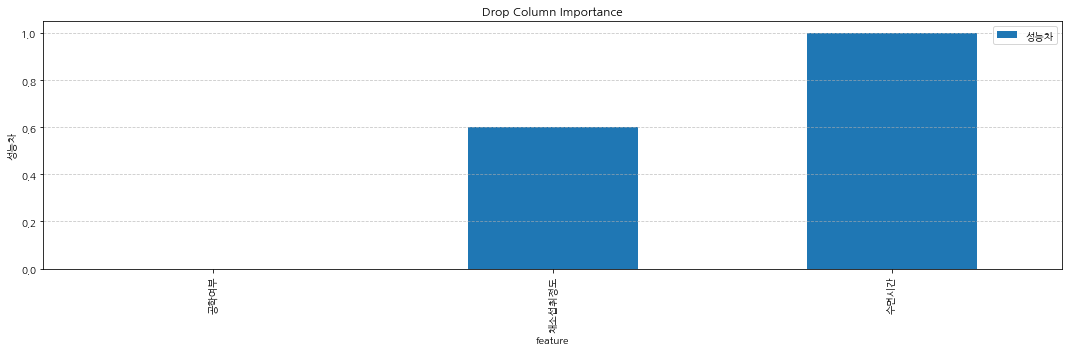

In [20]:
#최적의 모델 mlp 스켈레톤
full_model_score = xgb.score(train_X_d, train_Y)

drop_imp = {}

for col in train_X.columns: #const 제외
    tmp_X = train_X.drop(columns=col)
    tmp_X = pd.get_dummies(tmp_X, drop_first=True)
    reduce_model = XGBClassifier(random_state=42)
    reduce_model.fit(tmp_X, train_Y)
    reduce_score = accuracy_score(train_Y, reduce_model.predict(tmp_X))
    drop_imp[col] = full_model_score - reduce_score
    #정규화
    tt = pd.Series(drop_imp)
    dci_score = (tt - tt.min())/(tt.max()-tt.min())
    dci_dt = pd.DataFrame(dci_score, columns=['성능차']).sort_values(by='성능차', ascending=True)
display(dci_dt)

# 시각화
ax = dci_dt.plot(kind='bar', figsize=(15, 5))
# 축 레이블 및 제목 설정
ax.set_xlabel('feature')
ax.set_ylabel('성능차')
ax.set_title('Drop Column Importance')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Drop column importance 의 경우에는 수면시간>채소섭취 정도가 모델 성능에 영향을 미치며, 
공학여부는 아무런 영향을 미치지 않는 것을 알 수 있다.  
공학여부를 제외하는 것을 고려한다.

### 2-6] 두 모형의 ROC curve를 시각화하시오(겹쳐그릴 것).

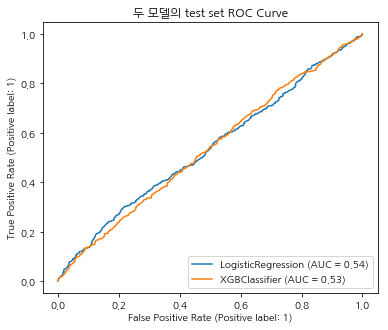

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
from sklearn.metrics import plot_roc_curve
#test set 기준 roc curve
roc_lr = plot_roc_curve(lr, test_X_d, test_Y, ax=ax)
roc_xgb = plot_roc_curve(xgb, test_X_d, test_Y, ax=ax)
ax.set_title("두 모델의 test set ROC Curve")
plt.show()

두 모델의 roc_curve결과, 로지스틱 회귀모형의 성능이 미세하게 좋음을 알 수 있으나,  
auc 점수 0.5에 가까워 거의 동전 던지기 수준의 낮은 성능을 보임을 알 수 있다.

# 통계

## 3번
어느 공장에서 제품을 생산하는데, 생산 과정은 평균 $\theta$와 분산 ($100^2$)인 
정규분포 $N(\theta, 100^2)$를 따른다. 또한, 평균이 $100$이고 분산이 $300^2$인 사전확률분포 $N(100, 300^2)$를 따른다.

관측된 제품의 값이 126일 때, 모집단 평균 $\theta$의 사후확률분포(사후평균)를 구하여라.

 베이즈 추론 문제이다. 사후분포는 사전분포와 데이터를 통해 얻어진 우도함수를 결합해서 구할 수 있다.  
 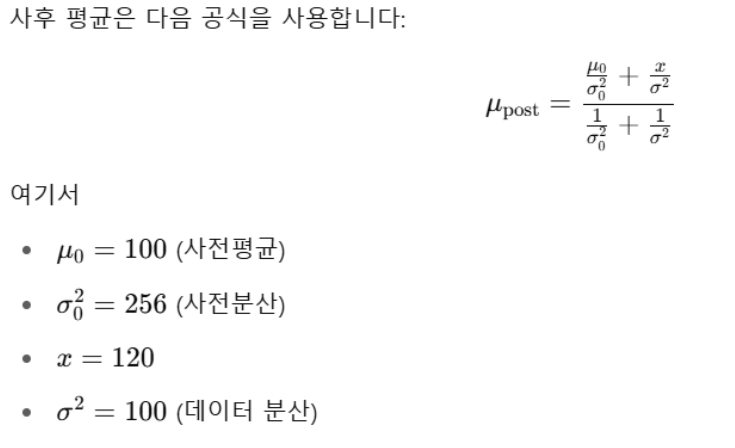

In [24]:
u0 = 100 # 사전평균
var0 = 300**2 #사전분산
x = 126 # 관측된 값
var = 100**2 # 데이터의 분산

u_post = (u0/var0+x/var)/(1/var0+1/var)

print(f"모집단의 사후평균: {u_post}")

모집단의 사후평균: 123.39999999999999


## 4번
- 데이터 출처 : https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset 후처리    
- 데이터 링크 : https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/31/adp_31_5_advertising.csv    
- 데이터 설명 : TV, Radio, Newspaper에 각각 광고비(달러)를 다르게 했을때 매출액 (Sales , 밀리언달러)를 나타내는 데이터    
- 종속변수 : Sales    

In [198]:
d4= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/31/adp_31_5_advertising.csv')
d4.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [199]:
d4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### 4-1
**회귀 모델링 후 유의하지 않는변수 파악**   

In [200]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols(formula='Sales~TV+Radio+Newspaper', data=d4).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           8.13e-99
Time:                        22:22:24   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6251      0.308     15.041      0.0

유의수준 5% 하에서 종속변수를 판매량으로 설정 후 회귀모델을 적합하였다.  
설명, 조정된 설명변수는 0.903, 0.901으로 높으며, p-value 8.13e-99으로 통계적으로 유의한 모델이다.  
신문 변수가 0.954로 0.05보다 크므로 통계적으로 유의하지 않다.

나머지 TV, Radio의 계수는 통계적으로 유의하며, 양의 계수로 TV/라디오 광고비가 커질 수록 판매량이 늘어나는 경향이 있다. 

## 4-2
**변수 선택시 먼저 제거 될 변수 및 근거 제시**

- 상관관계가 매우 낮은 변수 (독립변수 vs 종속변수 간)
- 다중공선성이 높은 변수 (VIF가 높은 경우)
- 결측치가 많은 변수
- 분산이 거의 없는 변수
- 도메인 지식에 기반한 불필요한 변수  
위 회귀분석 결과, Newspaper_Ad_Budget는 판매수익과 유의미한 영향이 없었으며 계수 또한 0에 가까운 값을 가진다.  
또한 선형 상관관계 분석에서도 판매수익과 낮은 상관관계를 가지므로 제거한다.

### 4-3
**VIF를 통한 다중공선성 진단**

In [201]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = model.model.exog #모델의 입력값
vif = pd.DataFrame(columns=['name', 'vif']) #데이터프레임화

vif['name'] = model.model.exog_names #독립변수명
vif['vif'] = [variance_inflation_factor(x, i) for i in range(x.shape[1])]
display(vif[1:])

,name,vif
1,TV,1.004611
2,Radio,1.144952
3,Newspaper,1.145187


앞서 선형회귀 모델학습에 사용된 입력값을 활용하여 vif를 통한 다중공선성 진단을 하였다.  
모든 독립변수의 vif가 1에 가까운 낮은 값으로 다중공선성은 관찰되지 않는다. 

## 5번
데이터 링크 : https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/31/adp_31_7.csv

데이터 설명 : A,B,C,D,E 영업사원의 각 계약 성사 유무 (1:계약 , 0:미계약) 를 나타낸 데이터이다. 영업사원의 평균 계약 성사 건수는 같은지 통계 검정하라

In [202]:
import pandas as pd
d5 =pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/31/adp_31_7.csv',index_col = 0)
d5.head()

,A,B,C,D,E
contract_1,1,0,1,1,1
contract_2,0,1,0,1,0
contract_3,1,0,0,0,0
contract_4,0,1,1,1,1
contract_5,0,1,0,1,0


k 개의 그룹(영업사원)별 1~5 조건 이진(계약/미계약) 반복측정 문제로 코크란-Q 검정 문제이다.   

<가설수립>
- 귀무가설: 영업사원의 평균 계약 성사 건수는 같다. 
- 대립가설: 적어도 한 명의 영업사원의 평균계약 성사건수는 다르다.

In [203]:
from statsmodels.stats.contingency_tables import cochrans_q

rs = cochrans_q(d5.values)
stat, p = rs.statistic, rs.pvalue

print(f"통계량: {stat:.3f}")
print(f"p-value: {p:.3f} 귀무가설", "기각" if p < 0.05 else "기각불가(같음)")

통계량: 4.516
p-value: 0.341 귀무가설 기각불가(같음)


## 6번
1주에 평균적으로 2.2마리의 강아지가 버려진다고 한다. 

1) 다음주에 개가 한마리도 버려지지 않을 확률

2) 다음주에 적어도 두마리 이상 버려질 확률 

In [204]:
from scipy.stats import poisson

lam = 2.2 #단위시간당 발생이벤트 수
sv1 = poisson.pmf(0, lam)
sv2 = 1- poisson.cdf(1, lam)

print(f"다음주에 개가 한마리도 버려지지 않을 확률: {sv1}")
print(f"다음주에 적어도 두마리 이상 버려질 확률: {sv2}")

다음주에 개가 한마리도 버려지지 않을 확률: 0.11080315836233387
다음주에 적어도 두마리 이상 버려질 확률: 0.6454298932405317
